# Working with Healthcare Time Series in pandas
### A hands-on tutorial for clinicians learning Python

**What you'll learn.** Hospital data is full of *time*: admission dates, discharge
dates, dates of birth, day-by-day charges. In this notebook we take a real (anonymized)
hospital billing extract and learn how to turn raw date columns into a proper
**time series** we can slice, summarize, smooth, and plot with `pandas`.

We'll frame every step around a clinical or operational question you might actually ask:

1. **Core essentials** — parsing dates, computing age and length of stay, indexing by
   date, and rolling charges up to a **daily** and **weekly** level.
2. **Rolling & cumulative views** — 3-day moving averages, running totals, and day-to-day
   percent change to see momentum in spending.
3. **Grouped time series** — comparing **ER vs. inpatient** trends, and charges by hospital.
4. **Plotting trends** — line, bar, and cumulative charts straight from `pandas`.

> **The dataset.** Each row is a single **billing line item** (one lab, one drug, one
> service), not a whole visit. 307 line items span **16 patients** across **6 hospitals**
> during **January 2020**. Keep this *grain* in mind: to talk about "a day" or "a patient"
> we have to **aggregate** the line items up.

*No prior pandas experience assumed — run each cell top to bottom with Shift+Enter.*


## 0. Setup

We import three libraries:

- **pandas** (`pd`) — the workhorse for tabular data and time series.
- **numpy** (`np`) — numerical helpers.
- **matplotlib** (`plt`) — plotting. `pandas` can draw charts directly using it.

The `set_option` lines just make tables and plots easier to read.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)   # show every column
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4)        # default chart size
plt.rcParams["axes.grid"] = True

print("pandas version:", pd.__version__)

pandas version: 2.2.3


### Load the data — straight from GitHub

`pandas` can read a CSV from a **URL** exactly as it reads a local file, so learners don't
need to download anything first — just an internet connection. We point `read_csv` at the
public dataset on GitHub. `read_csv` returns a **DataFrame**: a spreadsheet in memory.

In [42]:
DATA_URL = ("https://github.com/thousandoaks/Python4DS-I/raw/"
            "main/datasets/HealthcareDataset_PublicRelease.csv")

df = pd.read_csv(DATA_URL)

print("Rows, columns:", df.shape)
df.head()

Rows, columns: (52563, 17)


,Id,MemberName,MemberID,County,MedicalClaim,ClaimItem,HospitalName,HospitalType,StartDate,EndDate,PrincipalDiagnosisDesc,PrincipalDiagnosis,RevenueCodeDesc,RevenueCode,TypeFlag,BirthDate,TotalExpenses
0,634363,e659f3f4,6a380a28,6f943458,c1e3436737c77899,18,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DET...,636.0,ER,1967-05-13,15.148
1,634364,e659f3f4,6a380a28,6f943458,c1e3436737c77899,21,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DET...,636.0,ER,1967-05-13,3.073
2,634387,e659f3f4,6a380a28,6f943458,c1e3436737c77899,10,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,LABORATORY - CLINICAL DIAGNOSTIC: HEMATOLOGY,305.0,ER,1967-05-13,123.900
3,634388,e659f3f4,6a380a28,6f943458,c1e3436737c77899,20,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DET...,636.0,ER,1967-05-13,7.511
4,634389,e659f3f4,6a380a28,6f943458,c1e3436737c77899,19,04b77561,HOSPITAL,2020-01-08,2020-01-08,Epigastric pain,R10.13,DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DET...,636.0,ER,1967-05-13,8.631


### A first look at the columns

Notice the columns we care about for time analysis: `StartDate` (admission),
`EndDate` (discharge), and `BirthDate`. Let's check their data **types**.

In [43]:
df.dtypes

Id                          int64
MemberName                 object
MemberID                   object
County                     object
MedicalClaim               object
ClaimItem                   int64
HospitalName               object
HospitalType               object
StartDate                  object
EndDate                    object
PrincipalDiagnosisDesc     object
PrincipalDiagnosis         object
RevenueCodeDesc            object
RevenueCode               float64
TypeFlag                   object
BirthDate                  object
TotalExpenses             float64
dtype: object

**The catch.** `StartDate`, `EndDate`, and `BirthDate` come in as `object` — that means
plain **text strings**, not real dates. To pandas, `"2020-01-08"` is currently just a word.
We can't subtract dates, sort chronologically, or resample until we fix this. That's step 1.

---
## 1. Core essentials — from date strings to a time series

### 1.1 Parse the dates

`pd.to_datetime()` converts text into real timestamps. We loop over the three date columns
and overwrite each one with its parsed version.

In [44]:
for col in ["StartDate", "EndDate", "BirthDate"]:
    df[col] = pd.to_datetime(df[col])

df[["StartDate", "EndDate", "BirthDate"]].dtypes

StartDate    datetime64[ns]
EndDate      datetime64[ns]
BirthDate    datetime64[ns]
dtype: object

They're now `datetime64[ns]` — genuine dates. Everything below depends on this one step.

### 1.2 The `.dt` accessor — pulling pieces out of a date

Once a column is a datetime, `.dt` unlocks its parts: `.year`, `.month`, `.day`,
`.day_name()`, `.dayofweek`, and many more. Clinically useful for asking *"do admissions
cluster on certain weekdays?"*

In [45]:
df["AdmissionDay"]     = df["StartDate"].dt.day          # day of month (1-31)
df["AdmissionWeekday"] = df["StartDate"].dt.day_name()   # 'Monday', ...

df[["StartDate", "AdmissionDay", "AdmissionWeekday"]].head()

,StartDate,AdmissionDay,AdmissionWeekday
0,2020-01-08,8,Wednesday
1,2020-01-08,8,Wednesday
2,2020-01-08,8,Wednesday
3,2020-01-08,8,Wednesday
4,2020-01-08,8,Wednesday


### 1.3 Date arithmetic — length of stay and patient age

Subtracting two datetime columns gives a **Timedelta**. Its `.dt.days` attribute converts
that gap to whole days. Two classic clinical features fall right out:

- **Length of stay** = discharge − admission
- **Age at admission** = admission − date of birth (divide days by 365.25 for years)

In [46]:
df["LengthOfStayDays"] = (df["EndDate"] - df["StartDate"]).dt.days
df["AgeYears"] = ((df["StartDate"] - df["BirthDate"]).dt.days / 365.25).astype(int)

df[["MemberID", "StartDate", "EndDate", "LengthOfStayDays",
    "BirthDate", "AgeYears"]].head()

,MemberID,StartDate,EndDate,LengthOfStayDays,BirthDate,AgeYears
0,6a380a28,2020-01-08,2020-01-08,0,1967-05-13,52
1,6a380a28,2020-01-08,2020-01-08,0,1967-05-13,52
2,6a380a28,2020-01-08,2020-01-08,0,1967-05-13,52
3,6a380a28,2020-01-08,2020-01-08,0,1967-05-13,52
4,6a380a28,2020-01-08,2020-01-08,0,1967-05-13,52


### 1.4 A DatetimeIndex — make time the backbone of the table

For time-series work we move the date **into the index**. With `set_index("StartDate")`
followed by `sort_index()`, the DataFrame is ordered chronologically and we can select
date ranges with intuitive label slicing.

In [47]:
ts = df.set_index("StartDate").sort_index()

# Every line item admitted between Jan 5 and Jan 10 (inclusive):
ts.loc["2020-01-05":"2020-01-10", ["MemberID", "TypeFlag", "TotalExpenses"]].head(10)

,MemberID,TypeFlag,TotalExpenses
StartDate,,,
2020-01-05,006ba976,INP,12962.474
2020-01-05,0f1f68f4,INP,6273.925
2020-01-05,0f1f68f4,INP,5480.825
2020-01-05,0f1f68f4,INP,21563.325
2020-01-05,0f1f68f4,INP,582.400
2020-01-05,0f1f68f4,INP,144.669
2020-01-05,0f1f68f4,INP,1947.022
2020-01-05,0f1f68f4,INP,96.775
2020-01-05,0f1f68f4,INP,18889.325


> **Why this matters:** with a DatetimeIndex you can write `ts.loc["2020-01"]` for a
> whole month, `ts.loc["2020-01-08"]` for a single day, or a range like above — no manual
> string matching required.

### 1.5 Resampling — roll line items up to daily and weekly totals

This is the heart of time-series analysis. **`resample`** groups rows into fixed calendar
buckets. `"D"` = daily, `"W"` = weekly. Then we pick an aggregation:

- `.sum()` of `TotalExpenses` → **money spent per day**
- `.count()` → **number of billing lines per day** (a proxy for activity/volume)

Note how resampling **fills in every calendar day**, even days with no activity — a nice way
to reveal quiet periods.

In [48]:
daily_spend  = ts["TotalExpenses"].resample("D").sum()
daily_claims = ts["TotalExpenses"].resample("D").count()

daily = pd.DataFrame({"TotalExpenses": daily_spend,
                      "ClaimLines":    daily_claims})
daily.head(10)

,TotalExpenses,ClaimLines
StartDate,,
2020-01-01,448430.934,170
2020-01-02,997429.650,413
2020-01-03,773314.318,323
2020-01-04,302480.374,133
2020-01-05,478161.117,217
2020-01-06,657885.235,256
2020-01-07,574108.633,206
2020-01-08,220358.929,140
2020-01-09,585552.555,227


In [49]:
# The same idea at a weekly grain (weeks end on Sunday by default):
weekly_spend = ts["TotalExpenses"].resample("W").sum()
weekly_spend

StartDate
2020-01-05    2999816.393
2020-01-12    3476201.554
2020-01-19    3480062.817
2020-01-26    2528460.781
2020-02-02    3305230.194
2020-02-09    2162164.970
2020-02-16    3560949.049
2020-02-23    3258971.555
2020-03-01    1814262.884
2020-03-08    4320824.165
2020-03-15    2876581.414
2020-03-22    2749622.330
2020-03-29    1322137.467
2020-04-05    1524731.467
2020-04-12    1626185.911
2020-04-19    3433727.878
2020-04-26    1754394.831
2020-05-03    1095741.325
2020-05-10    1750081.564
2020-05-17    3229652.160
2020-05-24    2570696.401
2020-05-31    2986435.494
2020-06-07    1865177.510
2020-06-14    4750363.268
2020-06-21    2651476.478
2020-06-28    2372153.399
2020-07-05    3007199.209
2020-07-12    3146111.850
2020-07-19    3927467.355
2020-07-26    2467038.147
2020-08-02    4737567.100
2020-08-09    1941893.905
2020-08-16    3494897.966
2020-08-23    2002001.960
2020-08-30    2711966.320
2020-09-06    2294290.782
2020-09-13    1801519.265
2020-09-20    1935617.985
20

---
## 2. Rolling & cumulative views

Daily numbers are noisy. These techniques help you see the **trend** and the **running total**.

### 2.1 Rolling (moving) average — smoothing the noise

A **rolling window** averages each day with its neighbours. A 3-day rolling mean of charges
smooths out one-off spikes so an underlying trend is easier to see.
`min_periods=1` lets the first days compute even before a full window exists.

In [50]:
daily["Rolling3Day"] = daily["TotalExpenses"].rolling(window=3, min_periods=1).mean()
daily[["TotalExpenses", "Rolling3Day"]].head(10)

,TotalExpenses,Rolling3Day
StartDate,,
2020-01-01,448430.934,448430.934000
2020-01-02,997429.650,722930.292000
2020-01-03,773314.318,739724.967333
2020-01-04,302480.374,691074.780667
2020-01-05,478161.117,517985.269667
2020-01-06,657885.235,479508.908667
2020-01-07,574108.633,570051.661667
2020-01-08,220358.929,484117.599000
2020-01-09,585552.555,460006.705667


### 2.2 Cumulative and expanding views — the running story

- **`cumsum()`** gives a **running total** — cumulative charges to date (useful for budget burn).
- **`expanding().mean()`** is the average of *all days so far* — a running baseline.
- **`pct_change()`** is the day-over-day **% change** — momentum, positive or negative.

In [51]:
daily["CumulativeSpend"] = daily["TotalExpenses"].cumsum()
daily["ExpandingMean"]   = daily["TotalExpenses"].expanding().mean()
daily["PctChange"]       = daily["TotalExpenses"].pct_change()

daily[["TotalExpenses", "CumulativeSpend", "ExpandingMean", "PctChange"]].head(10).round(2)

,TotalExpenses,CumulativeSpend,ExpandingMean,PctChange
StartDate,,,,
2020-01-01,448430.93,448430.93,448430.93,NaN
2020-01-02,997429.65,1445860.58,722930.29,1.22
2020-01-03,773314.32,2219174.90,739724.97,-0.22
2020-01-04,302480.37,2521655.28,630413.82,-0.61
2020-01-05,478161.12,2999816.39,599963.28,0.58
2020-01-06,657885.24,3657701.63,609616.94,0.38
2020-01-07,574108.63,4231810.26,604544.32,-0.13
2020-01-08,220358.93,4452169.19,556521.15,-0.62
2020-01-09,585552.56,5037721.74,559746.86,1.66


Read the last column clinically: a `PctChange` of `1.5` means charges were **150% higher**
than the day before; `-0.4` means they fell 40%. The first value is `NaN` because there is
no prior day to compare against.

---
## 3. Grouped time series — comparing cohorts over time

Real questions are comparative: *ER vs. inpatient? Which hospital? Which weekday?* The pattern
is **`groupby` + `resample`**: split into groups, then build a time series within each.

### 3.1 ER vs. inpatient, day by day

`TypeFlag` marks each line as `ER` (emergency) or `INP` (inpatient). We group by it, resample
each group to daily totals, then `unstack` so the two cohorts sit side by side as columns.

In [52]:
by_type = (ts.groupby("TypeFlag")["TotalExpenses"]
             .resample("D").sum()
             .unstack("TypeFlag")
             .fillna(0))
by_type.head(10)

TypeFlag,ER,INP
StartDate,,
2020-01-01,74567.997,373862.937
2020-01-02,157772.160,839657.490
2020-01-03,143221.596,630092.722
2020-01-04,57772.701,244707.673
2020-01-05,93897.216,384263.901
2020-01-06,114893.212,542992.023
2020-01-07,15172.423,558936.210
2020-01-08,47442.752,172916.177
2020-01-09,48991.173,536561.382


### 3.2 The same result with a pivot table

If `groupby` + `resample` feels dense, `pivot_table` reads more like a spreadsheet pivot and
gives the identical daily ER-vs-INP matrix. Use whichever you find clearer.

In [53]:
pivot = pd.pivot_table(df, index="StartDate", columns="TypeFlag",
                       values="TotalExpenses", aggfunc="sum", fill_value=0)
pivot.head()

TypeFlag,ER,INP
StartDate,,
2020-01-01,74567.997,373862.937
2020-01-02,157772.160,839657.490
2020-01-03,143221.596,630092.722
2020-01-04,57772.701,244707.673
2020-01-05,93897.216,384263.901


### 3.3 Which hospital carried the most cost?

Group by hospital, total the charges, and sort. (Hospital names are anonymized hashes.)

In [54]:
by_hospital = df.groupby("HospitalName")["TotalExpenses"].sum().sort_values(ascending=False)
by_hospital.round(2)

HospitalName
ae46acbf    35607795.34
446442f4    21510072.62
a9bf1474    12301490.14
4d103af0    10003798.48
2f45157f     8243036.66
               ...     
17b02468         550.20
fd89f646         466.34
1b158493         388.19
31f83aa7         344.40
ec18e375         280.70
Name: TotalExpenses, Length: 148, dtype: float64

### 3.4 Is there a weekday pattern in charges?

Using the `.dt.day_name()` feature from earlier, we can total charges by day of the week and
reorder them Monday→Sunday. This is a simple **seasonality** check.

In [55]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
                 "Friday", "Saturday", "Sunday"]
weekday_spend = (df.groupby(df["StartDate"].dt.day_name())["TotalExpenses"]
                   .sum()
                   .reindex(weekday_order)
                   .fillna(0))
weekday_spend.round(2)

StartDate
Monday       26219867.09
Tuesday      23571326.48
Wednesday    20704765.61
Thursday     19971373.93
Friday       21191035.40
Saturday     14610974.83
Sunday       17502570.75
Name: TotalExpenses, dtype: float64

---
## 4. Plotting trends

`pandas` draws charts directly with `.plot()`. Because our data already has a DatetimeIndex,
the time axis is handled automatically.

### 4.1 Daily charges with a smoothed trend line

Raw daily charges (dots) with the 3-day rolling average (thick line) laid on top — the classic
way to show a noisy signal *and* its trend together.

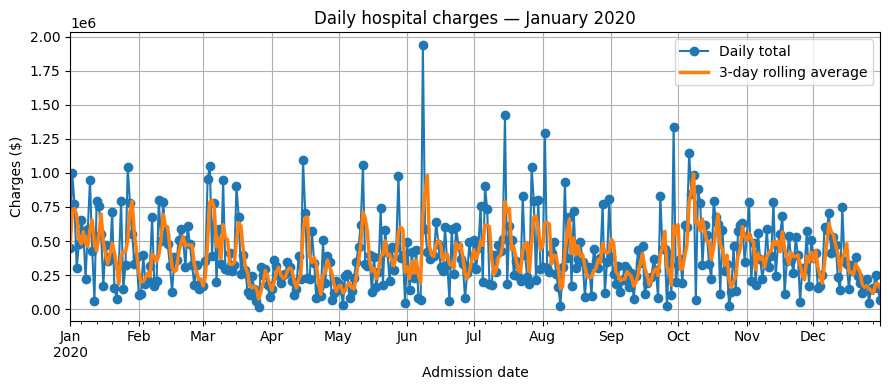

In [56]:
fig, ax = plt.subplots()
daily["TotalExpenses"].plot(ax=ax, marker="o", label="Daily total")
daily["Rolling3Day"].plot(ax=ax, linewidth=2.5, label="3-day rolling average")
ax.set_title("Daily hospital charges — January 2020")
ax.set_ylabel("Charges ($)")
ax.set_xlabel("Admission date")
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 ER vs. inpatient over time

Plotting the two-column `by_type` table draws one line per cohort — an immediate visual answer
to *"when do ER vs. inpatient costs spike?"*

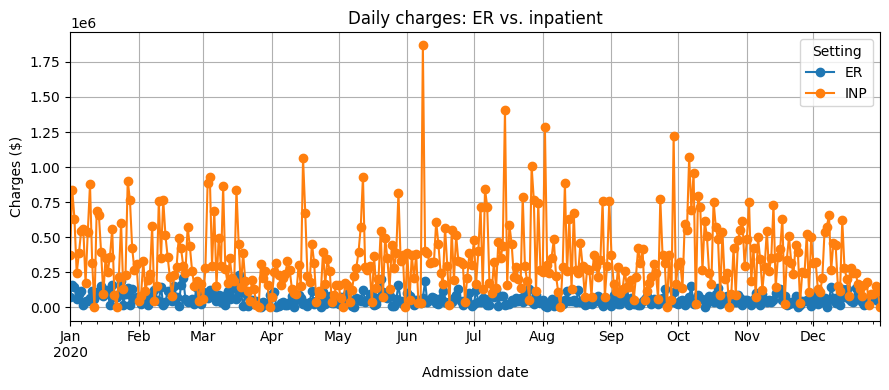

In [57]:
ax = by_type.plot(marker="o")
ax.set_title("Daily charges: ER vs. inpatient")
ax.set_ylabel("Charges ($)")
ax.set_xlabel("Admission date")
ax.legend(title="Setting")
plt.tight_layout()
plt.show()

### 4.3 Cumulative spend — the budget-burn curve

A running total climbs steeply on busy days and flattens on quiet ones — how finance teams
watch a budget deplete.

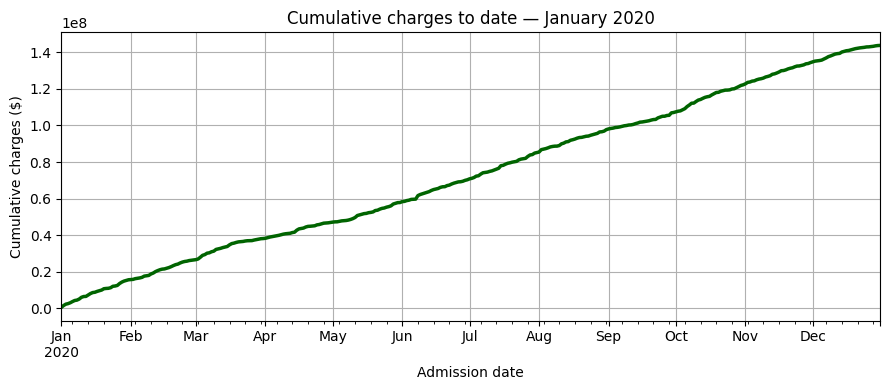

In [58]:
ax = daily["CumulativeSpend"].plot(linewidth=2.5, color="darkgreen")
ax.set_title("Cumulative charges to date — January 2020")
ax.set_ylabel("Cumulative charges ($)")
ax.set_xlabel("Admission date")
plt.tight_layout()
plt.show()

### 4.4 Daily billing volume — a bar chart

Counts (not dollars) show operational activity. We format the dates as short labels so the
x-axis stays readable.

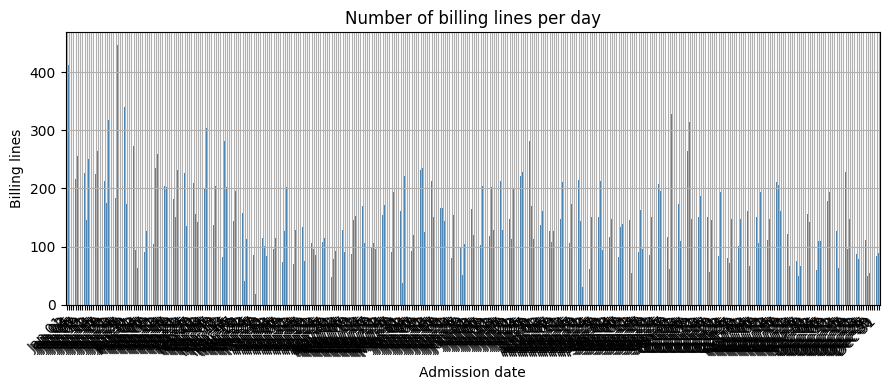

In [59]:
ax = daily["ClaimLines"].plot(kind="bar", color="steelblue")
ax.set_title("Number of billing lines per day")
ax.set_ylabel("Billing lines")
ax.set_xlabel("Admission date")
ax.set_xticklabels([d.strftime("%b %d") for d in daily.index], rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 4.5 Weekday pattern

Finally, the weekday seasonality check as a bar chart.

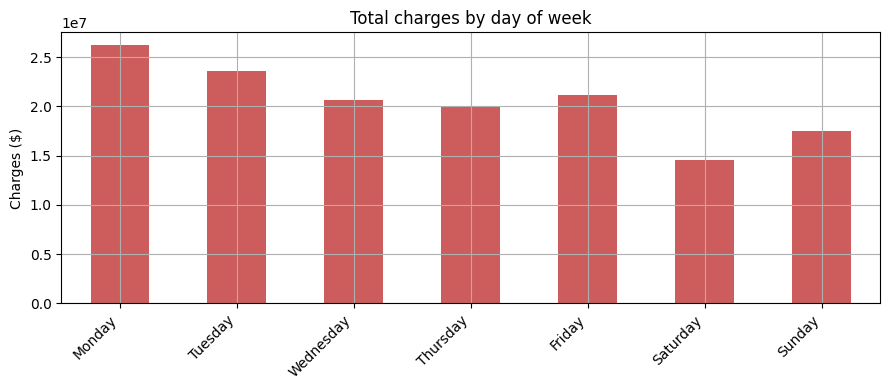

In [60]:
ax = weekday_spend.plot(kind="bar", color="indianred")
ax.set_title("Total charges by day of week")
ax.set_ylabel("Charges ($)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()